# Notebook 5 - Feature Engineering

**Goal** - build 9 behavioural features from raw transaction and listening data, validate their churn signal, and remove redundant ones.

This notebook feeds directly into notebook 6. The output file `master_fe.csv` is the only input the model sees.

## Setup and load data

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED = Path(r"C:\kkbox-retention-analytics\data\processed")
master = pd.read_csv(PROCESSED / "master.csv", parse_dates=['registration_init_time', 'last_active_date'])
master = master.drop(columns=['bd'], errors='ignore')
print(master.shape, master['is_churn'].mean().round(4))

(1082190, 24) 0.0915


## Rate features

Normalise raw counts by time or activity so they're comparable across subscribers with different tenure lengths.

In [24]:
master['cancel_rate']      = master['cancel_count'] / master['txn_count'].clip(lower=1)
master['activity_rate']    = master['activity_day_count'] / master['tenure_days'].clip(lower=1)
master['txn_per_month']    = master['txn_count'] / (master['tenure_days'] / 30).clip(lower=1)
master['revenue_per_month']= master['total_paid']  / (master['tenure_days'] / 30).clip(lower=1)

## Check distributions before clipping

In [25]:
rate_features = ['cancel_rate', 'activity_rate', 'txn_per_month', 'revenue_per_month']
print(master[rate_features].describe().round(3))

       cancel_rate  activity_rate  txn_per_month  revenue_per_month
count  1082190.000     955126.000     961431.000         961431.000
mean         0.017          0.328          0.626             83.712
std          0.045          0.264          0.390             56.490
min          0.000          0.000          0.006              0.000
25%          0.000          0.112          0.282             43.545
50%          0.000          0.259          0.574             86.207
75%          0.000          0.500          1.000            108.000
max          1.000          1.000         28.824           4294.706


## Clip outliers

A handful of subscribers have extreme values (e.g. 50 transactions in one month). We clip at the 99th percentile so they don't distort the model.

In [26]:
print(master[['txn_per_month', 'revenue_per_month']].quantile([0.95, 0.99, 0.999]).round(2))
#check the extremes of features

       txn_per_month  revenue_per_month
0.950           1.14             159.37
0.990           1.46             210.56
0.999           2.07             418.60


In [27]:
master['txn_per_month']     = master['txn_per_month'].clip(upper=3)
master['revenue_per_month'] = master['revenue_per_month'].clip(upper=500)

## Trajectory features

How behaviour changed over time — not just what the subscriber did, but whether they're becoming more or less engaged.

In [28]:
master['onboarding_drop'] = (
    master['first_week_depth'] / master['avg_num_unq'].replace(0, np.nan)
).fillna(1.0)

In [29]:
master['recency_ratio'] = (
    master['days_since_last_active'] / master['tenure_days'].clip(lower=1)
)

## Check trajectory distributions

In [30]:
print(master[['onboarding_drop', 'recency_ratio']].describe().round(3))

       onboarding_drop  recency_ratio
count      1082190.000     955126.000
mean             0.477          0.051
std              0.718          0.157
min              0.000          0.000
25%              0.000          0.001
50%              0.000          0.003
75%              1.000          0.014
max             38.743          1.000


In [31]:
print(master['onboarding_drop'].quantile([0.95, 0.99, 0.999]).round(3))

0.950    1.774
0.990    2.928
0.999    5.267
Name: onboarding_drop, dtype: float64


## Clip trajectory outliers

In [32]:
master['onboarding_drop'] = master['onboarding_drop'].clip(upper=6)
master['dormancy_risk'] = master['days_since_last_active'] * (1 - master['auto_renew_history'])
master['plan_commitment'] = master['avg_plan_duration'] * master['auto_renew_history']
master['engagement_quality'] = master['avg_num_unq'] * master['avg_completion_rate']
master['listen_hrs_per_day'] = master['avg_total_secs'] / 3600

## Composite features

Combine multiple signals into a single risk indicator.

In [33]:
composite_features = ['dormancy_risk', 'plan_commitment', 'engagement_quality', 'listen_hrs_per_day']
print(master[composite_features].describe().round(3))

       dormancy_risk  plan_commitment  engagement_quality  listen_hrs_per_day
count     955159.000      1082190.000          955159.000          955159.000
mean           2.157           25.430              17.757               1.829
std           16.912           12.938              14.689               1.481
min            0.000            0.000               0.000               0.000
25%            0.000           28.714               9.065               0.958
50%            0.000           30.000              14.486               1.464
75%            0.000           30.000              21.958               2.224
max          819.000          308.750             319.618              24.000


In [34]:
print(master[['dormancy_risk', 'engagement_quality']].quantile([0.95, 0.99, 0.999]).round(2))

       dormancy_risk  engagement_quality
0.950            6.0               43.45
0.990           49.0               77.07
0.999          200.0              128.52


## Null audit — confirm missingness is already captured

In [35]:
all_features = [
    'cancel_rate', 'activity_rate', 'txn_per_month', 'revenue_per_month',
    'onboarding_drop', 'recency_ratio',
    'dormancy_risk', 'plan_commitment', 'engagement_quality', 'listen_hrs_per_day'
]

null_summary = (
    master[all_features]
    .isnull()
    .sum()
    .rename('null_count')
    .to_frame()
    .assign(null_pct=lambda df: (df['null_count'] / len(master) * 100).round(2))
    .sort_values('null_count', ascending=False)
)
print(null_summary)

                    null_count  null_pct
activity_rate           127064     11.74
recency_ratio           127064     11.74
engagement_quality      127031     11.74
listen_hrs_per_day      127031     11.74
dormancy_risk           127031     11.74
txn_per_month           120759     11.16
revenue_per_month       120759     11.16
cancel_rate                  0      0.00
onboarding_drop              0      0.00
plan_commitment              0      0.00


In [36]:
print(master[['has_logs', 'has_tx']].value_counts())
print(f"\nhas_logs churn rate: {master.groupby('has_logs')['is_churn'].mean().round(3)}")
print(f"has_tx churn rate:   {master.groupby('has_tx')['is_churn'].mean().round(3)}")

has_logs  has_tx
1         1         955159
0         1         127031
Name: count, dtype: int64

has_logs churn rate: has_logs
0    0.058
1    0.096
Name: is_churn, dtype: float64
has_tx churn rate:   has_tx
1    0.092
Name: is_churn, dtype: float64


## Correlation with churn — validate each feature earns its place

In [37]:
all_features = [
    'cancel_rate', 'activity_rate', 'txn_per_month', 'revenue_per_month',
    'onboarding_drop', 'recency_ratio',
    'dormancy_risk', 'plan_commitment', 'engagement_quality', 'listen_hrs_per_day',
    'has_logs'
]

## Multicollinearity check — find features that duplicate each other

In [38]:
churn_corr = (
    master[all_features + ['is_churn']]
    .corr()['is_churn']
    .drop('is_churn')
    .sort_values(key=abs, ascending=False)
)
print(churn_corr.round(3))

plan_commitment      -0.393
dormancy_risk         0.329
txn_per_month        -0.202
cancel_rate           0.194
recency_ratio         0.068
has_logs              0.042
revenue_per_month    -0.034
activity_rate        -0.028
listen_hrs_per_day    0.023
engagement_quality    0.023
onboarding_drop       0.011
Name: is_churn, dtype: float64


## Drop redundant features and define final set

`listen_hrs_per_day` correlated 0.91 with `engagement_quality`. `revenue_per_month` correlated 0.82 with `txn_per_month`. Both dropped.

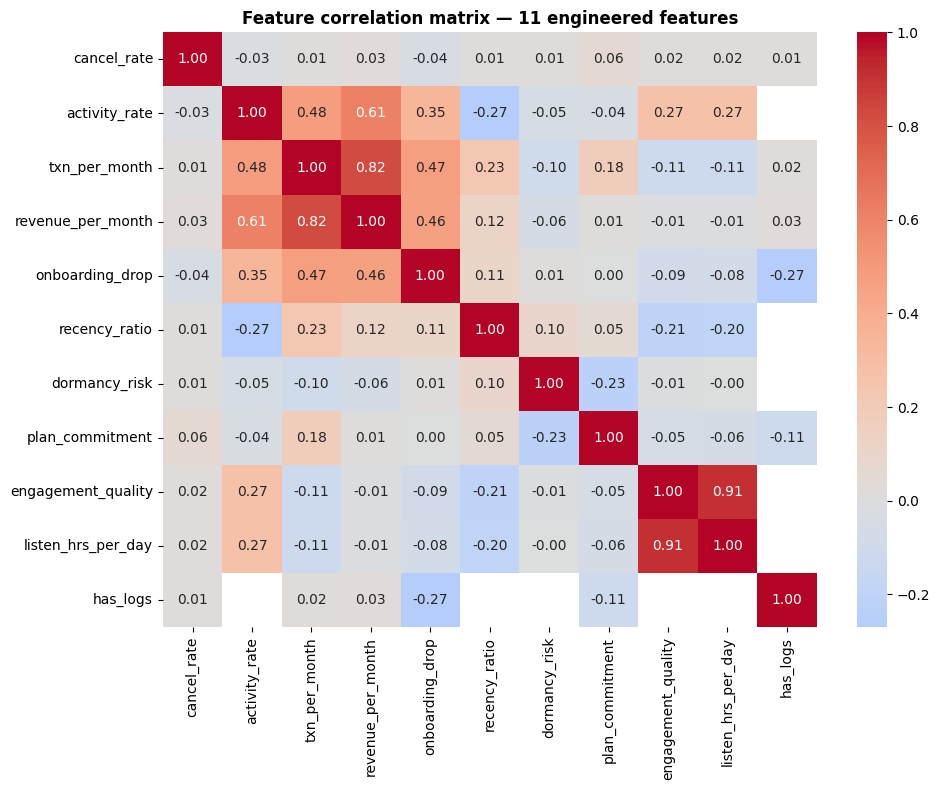

In [39]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    master[all_features].corr().round(2),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Feature correlation matrix — 11 engineered features', fontweight='bold')
plt.tight_layout()
plt.show()

## Save to master_fe.csv

In [40]:
all_features = [
    'cancel_rate', 'activity_rate', 'txn_per_month',
    'onboarding_drop', 'recency_ratio', 'dormancy_risk',
    'plan_commitment', 'engagement_quality', 'has_logs'
]

## Conclusion

Raw counts tell you what happened. Features tell you what it means.

50 transactions over 3 years is very different from 50 transactions in one month — but the raw number looks identical. Rate, trajectory, and composite features capture that difference.

9 features remain after dropping 2 near-duplicates. All 9 go straight into notebook 6.